# Decision Tree on Wine Dataset

A Decision Tree is a supervised machine learning algorithm used for classification and regression tasks. It works by splitting the dataset into smaller subsets based on feature values and forming a tree-like structure of decisions. Each internal node of the tree represents a decision based on a feature, each branch represents the outcome of that decision, and each leaf node represents the final predicted class.

Decision Trees are easy to understand and interpret because they mimic human decision-making processes. The algorithm selects the most important features to split the data at each step using measures such as Gini Index or Entropy. By repeatedly splitting the data, the model learns patterns that help classify new, unseen data accurately.

In this experiment, the Decision Tree classifier is applied to the Wine dataset to predict the class of wine samples based on their chemical properties.

In [13]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
columns = [
    "Class","Alcohol","Malic_Acid","Ash","Alcalinity_of_Ash","Magnesium",
    "Total_Phenols","Flavanoids","Nonflavanoid_Phenols","Proanthocyanins",
    "Color_Intensity","Hue","OD280_OD315","Proline"
]

df = pd.read_csv("wine.data", header=None, names=columns)

df.head()

,Class,Alcohol,Malic_Acid,Ash,Alcalinity_of_Ash,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280_OD315,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


###  Separate Features and Target

In [3]:
X = df.drop("Class", axis=1)
y = df["Class"]

### Train-Test Split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### Train Decision Tree Model

In [5]:
dt_model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=4,
    random_state=42
)

dt_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4, random_state=42)

### Make Predictions

In [6]:
y_pred = dt_model.predict(X_test)

### Evaluate Model

In [7]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9444444444444444


In [8]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[11  1  0]
 [ 0 14  0]
 [ 0  1  9]]


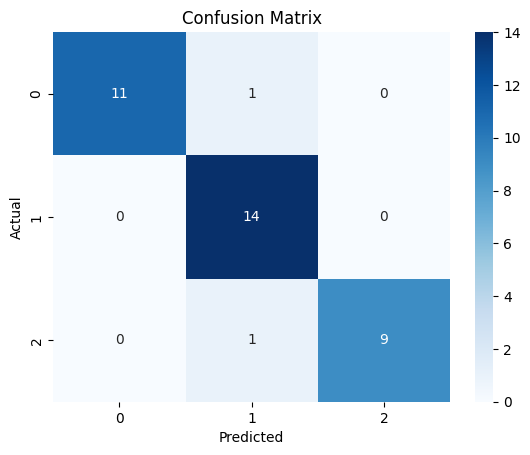

In [9]:
sns.heatmap(cm, annot=True, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [10]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       1.00      0.92      0.96        12
           2       0.88      1.00      0.93        14
           3       1.00      0.90      0.95        10

    accuracy                           0.94        36
   macro avg       0.96      0.94      0.95        36
weighted avg       0.95      0.94      0.94        36



### Visualize the Decision Tree

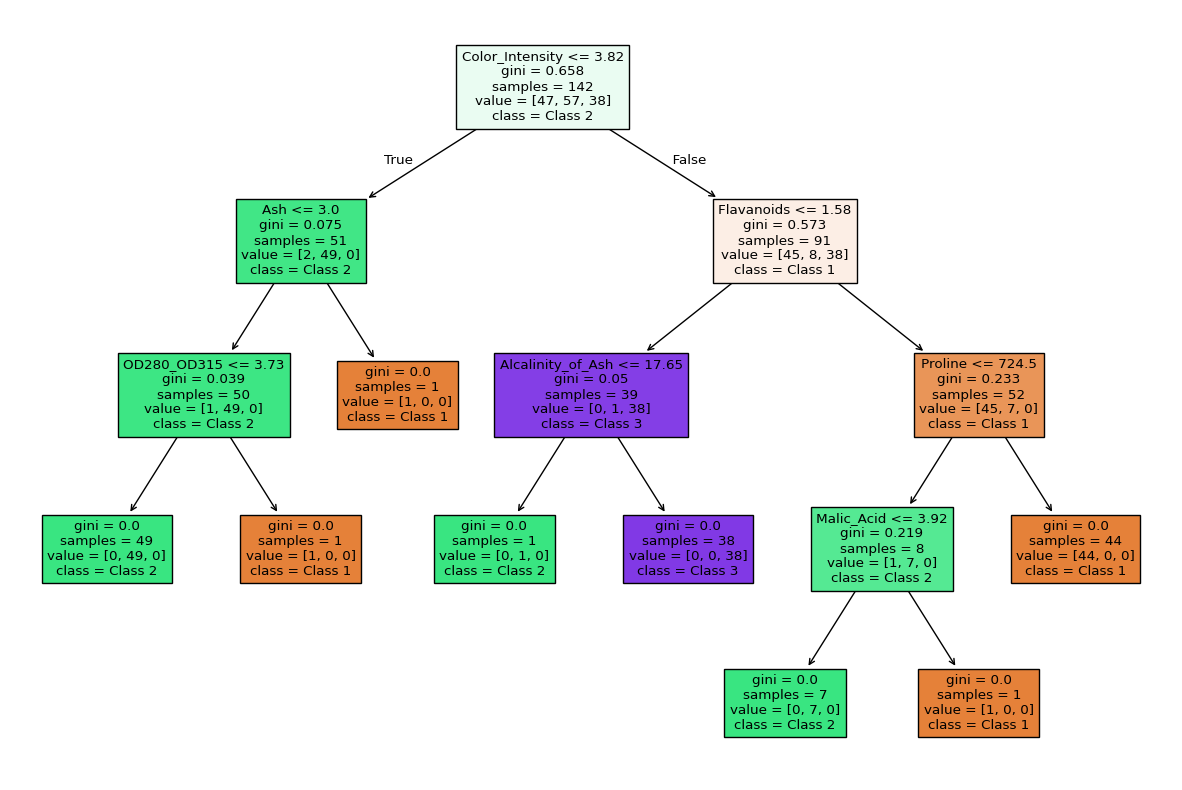

In [11]:
from sklearn.tree import plot_tree

plt.figure(figsize=(15,10))
plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=['Class 1','Class 2','Class 3'],
    filled=True
)
plt.show()

### Feature Importance

In [12]:
importance = pd.Series(dt_model.feature_importances_, index=X.columns)
importance.sort_values(ascending=False)

,0
Flavanoids,0.408073
Color_Intensity,0.400189
Proline,0.110985
OD280_OD315,0.020986
Alcalinity_of_Ash,0.020865
Ash,0.020163
Malic_Acid,0.018738
Magnesium,0.000000
Alcohol,0.000000
Proanthocyanins,0.000000


### Observations
	•	Decision Tree successfully classified wine samples.
	•	Some features like Proline and Alcohol strongly influence classification.
	•	Decision Trees are easy to interpret because they show clear decision rules.